In [1]:
!pip install -q xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import pickle, re
from transformers import pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [3]:
df = pd.read_csv('Corona_NLP_test (1).csv')

In [4]:
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,1,44953,NYC,02-03-2020,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative
1,2,44954,"Seattle, WA",02-03-2020,When I couldn't find hand sanitizer at Fred Me...,Positive
2,3,44955,NaN,02-03-2020,Find out how you can protect yourself and love...,Extremely Positive
3,4,44956,Chicagoland,02-03-2020,#Panic buying hits #NewYork City as anxious sh...,Negative
4,5,44957,"Melbourne, Victoria",03-03-2020,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserName       3798 non-null   int64 
 1   ScreenName     3798 non-null   int64 
 2   Location       2964 non-null   object
 3   TweetAt        3798 non-null   object
 4   OriginalTweet  3798 non-null   object
 5   Sentiment      3798 non-null   object
dtypes: int64(2), object(4)
memory usage: 178.2+ KB


In [6]:
df.dtypes

UserName          int64
ScreenName        int64
Location         object
TweetAt          object
OriginalTweet    object
Sentiment        object
dtype: object

In [7]:
df.columns

Index(['UserName', 'ScreenName', 'Location', 'TweetAt', 'OriginalTweet',
       'Sentiment'],
      dtype='object')

In [8]:
df.describe(include="all")

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
count,3798.000000,3798.000000,2964,3798,3798,3798
unique,NaN,NaN,1717,15,3798,5
top,NaN,NaN,United States,13-03-2020,TRENDING: New Yorkers encounter empty supermar...,Negative
freq,NaN,NaN,75,1233,1,1041
mean,1899.500000,46851.500000,NaN,NaN,NaN,NaN
std,1096.532489,1096.532489,NaN,NaN,NaN,NaN
min,1.000000,44953.000000,NaN,NaN,NaN,NaN
25%,950.250000,45902.250000,NaN,NaN,NaN,NaN
50%,1899.500000,46851.500000,NaN,NaN,NaN,NaN
75%,2848.750000,47800.750000,NaN,NaN,NaN,NaN


In [9]:
df.isna().sum()

UserName           0
ScreenName         0
Location         834
TweetAt            0
OriginalTweet      0
Sentiment          0
dtype: int64

In [10]:
df["Location"]=df["Location"].fillna("Unknown")

In [11]:
df.isna().sum()

UserName         0
ScreenName       0
Location         0
TweetAt          0
OriginalTweet    0
Sentiment        0
dtype: int64

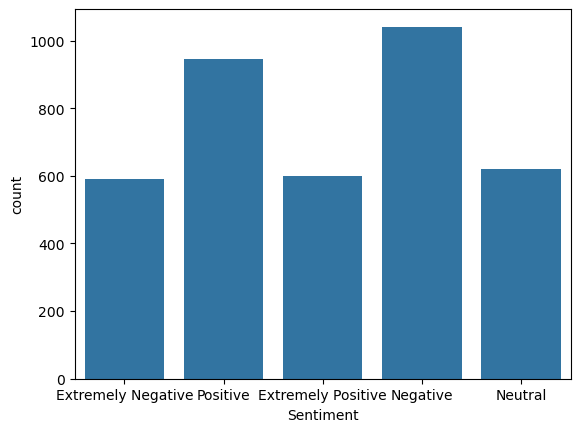

In [12]:
sns.countplot(x="Sentiment", data=df)
plt.show()

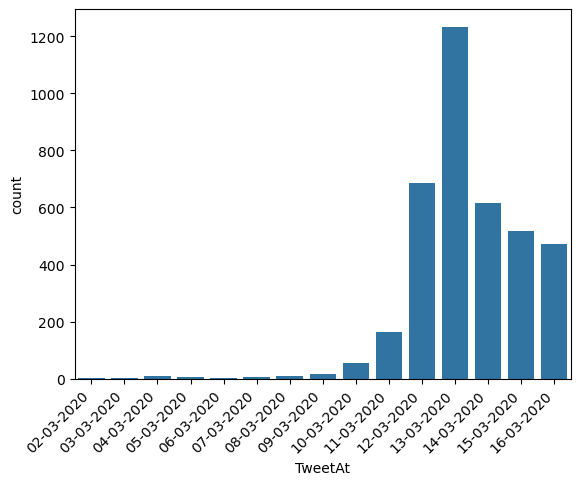

In [13]:
sns.countplot(x="TweetAt", data=df)
plt.xticks(rotation=45, ha="right")
plt.show()

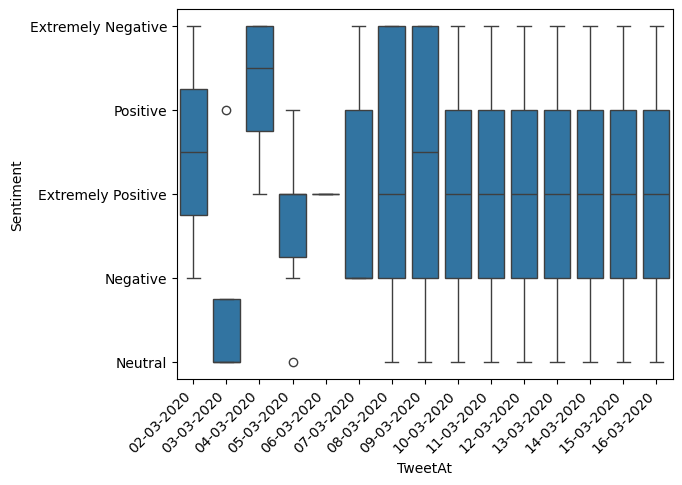

In [14]:
sns.boxplot(x="TweetAt", y="Sentiment", data=df)
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [20]:
df["clean_sentiment"]=df["Sentiment"].apply(clean_text)

In [21]:
X=df.drop(columns=["clean_sentiment"])
y=df["clean_sentiment"]

In [22]:
le=LabelEncoder()
y1=pd.DataFrame(le.fit_transform(y), columns=["Sentiment"], index=y.index)

In [23]:
y2=y1["Sentiment"]

In [24]:
X=pd.get_dummies(X, drop_first=True, dtype='int')

In [25]:
X.shape

(3798, 5534)

In [26]:
y2.shape

(3798,)

In [27]:
X_train, X_test, y_train, y_test= train_test_split(X, y2, test_size=0.2, random_state=42)

In [28]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [29]:
X_train.shape

(3038, 5534)

In [30]:
X_test.shape

(760, 5534)

In [31]:
y_test.shape

(760,)

In [32]:
y_train.shape

(3038,)

In [33]:
def sentiment_analysis(X_train, X_test, y_train, y_test):
    models={
        "Logistic Regression": LogisticRegression(multi_class="multinomial", max_iter=1000, random_state=42),
        "XGBoost Classifier": XGBClassifier(objective="multi:softprob", eval_metric="mlogloss", random_state=42)
    }
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        print("Classification Report:\n", classification_report(y_test, y_pred))
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
        print("Accuracy Score:", accuracy_score(y_test, y_pred))

In [34]:
print(sentiment_analysis(X_train, X_test, y_test, y_train))

ValueError: Found input variables with inconsistent numbers of samples: [3038, 760]

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 